In [28]:
"""
PROJECT TITLE: Oxymove (MOXY)
--------------------------------------------------
DESCRIPTION:
    This script processes raw NIRS data file collected with the Artinis Portalite and Semaxone device during a concentric or eccentric task. 
    The script will convert raw optical density data to hemoglobin concentration changes, apply a low-pass filter, and plot the results around specific event markers.

AUTHOR: Devaux Yann (EuroMov DHM / University of Montpellier)
CONTACT: yann.devaux@etu.umontpellier.fr
CREATED: 03/03/2026
VERSION: 0.0.1

INPUTS:
    - Compressed raw NIRS data (.snirf)
    - Event markers file (.tsv)
    - Configuration file (.json)

OUTPUTS:
    - various plots and measures

LIBRARIES:
    Mne, Matplotlib, Pandas
"""

'\nPROJECT TITLE: Oxymove (MOXY)\n--------------------------------------------------\nDESCRIPTION:\n    This script processes raw NIRS data file collected with the Artinis Portalite and Semaxone device during a concentric or eccentric task. \n    The script will convert raw optical density data to hemoglobin concentration changes, apply a low-pass filter, and plot the results around specific event markers.\n\nAUTHOR: Devaux Yann (EuroMov DHM / University of Montpellier)\nCONTACT: yann.devaux@etu.umontpellier.fr\nCREATED: 03/03/2026\nVERSION: 0.0.1\n\nINPUTS:\n    - Compressed raw NIRS data (.snirf)\n    - Event markers file (.tsv)\n    - Configuration file (.json)\n\nOUTPUTS:\n    - various plots and measures\n\nLIBRARIES:\n    Mne, Matplotlib, Pandas\n'

In [29]:
#To make sure to have all the required libraries installed, you can run the following command in your terminal: 
#pip install mne matplotlib pandas mne-bids

In [30]:
import mne 
import matplotlib.pyplot as plt
import pandas as pd
from mne_bids import BIDSPath, read_raw_bids

mne.viz.set_browser_backend("qt")


# Define the path to your file
raw = BIDSPath(subject='001', session='001', task='concentric',recording='portalite',
                     suffix='nirs', extension='.snirf', datatype='nirs',
                     root='C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\data\MOXY-bids')

# This automatically looks for the .tsv file and attaches it as annotations
raw = read_raw_bids(raw)


duration = raw.times[-1]


#Définir des segments, pour pouvoir les afficher uniquement


# 1. Convertir intensité → optical density
raw_od = mne.preprocessing.nirs.optical_density(raw)


# 2. Convertir OD → HbO / HbR via Beer-Lambert and set PPF
raw_hb = mne.preprocessing.nirs.beer_lambert_law(raw_od, ppf=4)
print(raw_hb)

# 3. Filtrer les données with a low-pass filter (cutoff at 5 Hz) and a butterworth filter of order 4.
raw_hb_filt = raw_hb.copy().filter(
    l_freq=0.01,
    h_freq=4,
    method="iir",
    iir_params=dict(order=4, ftype="butter"),
)

# 4. Display 20 secondes after the first event conc50. 
#event_time = events[events["trial_type"] == "Con50"]["onset"].values[0]

#5. center around 0 and take the air under the curve
#df['rab_hb_filt']
raw_hb_filt.plot(start=0, duration=duration)

Loading C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\data\MOXY-bids\sub-001\ses-001\nirs\sub-001_ses-001_task-concentric_recording-portalite_nirs.snirf
Found jitter of 0.000000% in sample times.
Reading events from C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\data\MOXY-bids\sub-001\ses-001\nirs\sub-001_ses-001_task-concentric_events.tsv.
Reading 0 ... 22351  =      0.000 ...  2235.051 secs...
<RawSNIRF | sub-001_ses-001_task-concentric_recording-portalite_nirs.snirf, 6 x 22352 (2235.2 s), ~1.0 MiB, data loaded>
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.01 - 4 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 0.01, 4.00 Hz: -6.02, -6.02 dB



<>:12: SyntaxWarning: invalid escape sequence '\P'
<>:12: SyntaxWarning: invalid escape sequence '\P'
C:\Users\dvxya\AppData\Local\Temp\ipykernel_33088\3916575410.py:12: SyntaxWarning: invalid escape sequence '\P'
  root='C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\data\MOXY-bids')
C:\Users\dvxya\AppData\Local\Temp\ipykernel_33088\3916575410.py:15: RuntimeWarning: Did not find any channels.tsv associated with sub-001_ses-001_task-concentric_recording-portalite.

The search_str was "C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\data\MOXY-bids\sub-001\**\nirs\sub-001_ses-001*channels.tsv"
  raw = read_raw_bids(raw)
C:\Users\dvxya\AppData\Local\Temp\ipykernel_33088\3916575410.py:15: RuntimeWarning: Unable to map the following column(s) to to MNE:
: 0
sexe: M
handedness: R
  raw = read_raw_bids(raw)


PROCESSING CONCENTRIC DATA

Processing Con30 series...
  Series 1: Mean HbR = -0.641 µM
  Series 2: Mean HbR = -0.846 µM
  Series 3: Mean HbR = -0.814 µM

Processing Con50 series...
  Series 1: Mean HbR = -1.147 µM
  Series 2: Mean HbR = -1.128 µM
  Series 3: Mean HbR = -1.355 µM

PROCESSING ECCENTRIC DATA
Loading C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\data\MOXY-bids\sub-001\ses-002\nirs\sub-001_ses-002_task-eccentric_recording-portalite_nirs.snirf
Found jitter of 0.000000% in sample times.
Reading events from C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\data\MOXY-bids\sub-001\ses-002\nirs\sub-001_ses-002_task-eccentric_events.tsv.
Reading 0 ... 22835  =      0.000 ...  2283.453 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.01 - 4 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs

C:\Users\dvxya\AppData\Local\Temp\ipykernel_33088\1677670891.py:84: RuntimeWarning: Did not find any channels.tsv associated with sub-001_ses-002_task-eccentric_recording-portalite.

The search_str was "C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\data\MOXY-bids\sub-001\**\nirs\sub-001_ses-002*channels.tsv"
  raw_ecc = read_raw_bids(raw_ecc)
C:\Users\dvxya\AppData\Local\Temp\ipykernel_33088\1677670891.py:84: RuntimeWarning: Unable to map the following column(s) to to MNE:
: 0
sexe: M
handedness: R
  raw_ecc = read_raw_bids(raw_ecc)



Processing Ecc30 series...
  Series 1: Mean HbR = -2.801 µM
  Series 2: Mean HbR = -1.512 µM
  Series 3: Mean HbR = -2.824 µM

Processing Ecc50 series...
  Series 1: Mean HbR = -3.454 µM
  Series 2: Mean HbR = -2.165 µM
  Series 3: Mean HbR = -3.021 µM


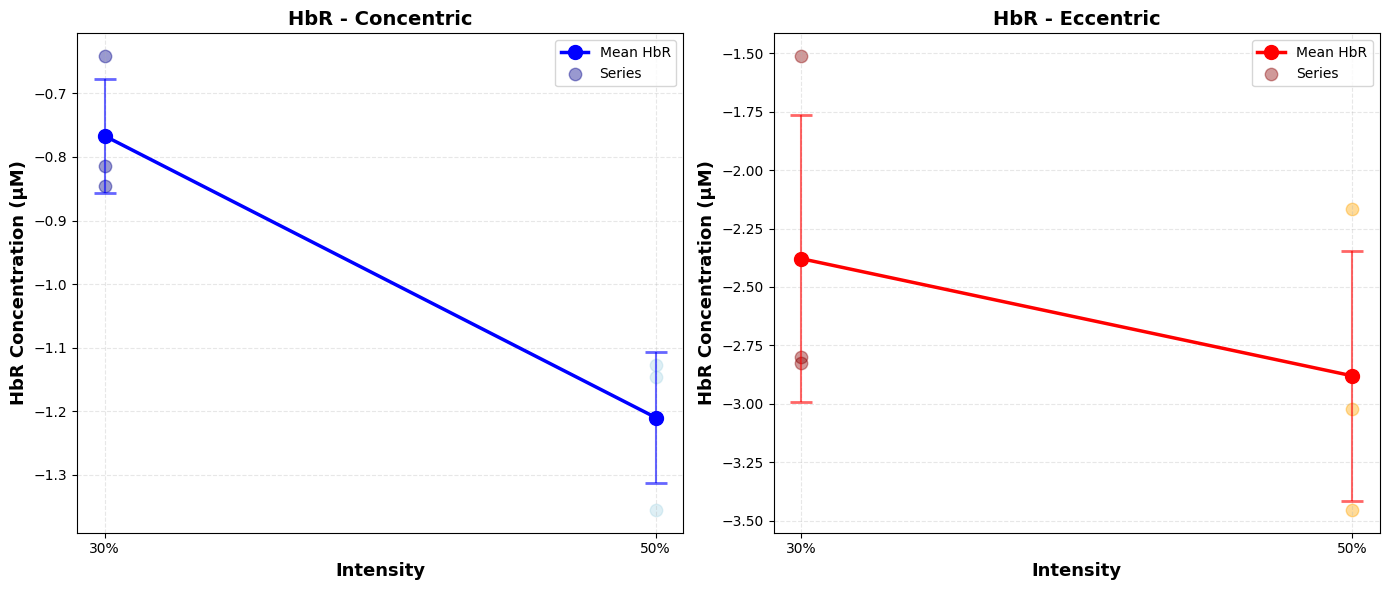


STATISTICS - HbR concentration as a function of intensity

CONCENTRIC - INTENSITY 30%
HbR: -0.767 ± 0.090 µM
Number of series: 3

CONCENTRIC - INTENSITY 50%
HbR: -1.210 ± 0.103 µM
Number of series: 3
Δ HbR (50%-30%): -0.443 µM (57.8%)

ECCENTRIC - INTENSITY 30%
HbR: -2.379 ± 0.613 µM
Number of series: 3

ECCENTRIC - INTENSITY 50%
HbR: -2.880 ± 0.535 µM
Number of series: 3
Δ HbR (50%-30%): -0.501 µM (21.1%)


In [ ]:
# This cell analyzes HbR concentration changes as a function of intensity for CONCENTRIC and ECCENTRIC tasks

import numpy as np

# ============================================================================
# CONCENTRIC DATA (left plot)
# ============================================================================
print("="*70)
print("PROCESSING CONCENTRIC DATA")
print("="*70)

# Load concentric events
events_con_df = pd.read_csv(
    r'C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\data\MOXY-bids\sub-001\ses-001\nirs\sub-001_ses-001_task-concentric_events.tsv',
    sep='\t'
)

# Filter for Con30 and Con50 events
con30_events = events_con_df[events_con_df['trial_type'] == 'Con30']
con50_events = events_con_df[events_con_df['trial_type'] == 'Con50']

# Get HbR channels
ch_names = raw_hb_filt.ch_names
hbr_channels = [ch for ch in ch_names if 'hbr' in ch.lower()]

# Duration of each contraction series
window_duration = 30

# Initialize storage for concentric
hbr_con30_means = []
hbr_con50_means = []

# Process Con30 series
print("\nProcessing Con30 series...")
for idx, row in con30_events.iterrows():
    onset = row['onset']
    tmin = onset
    tmax = onset + window_duration
    
    data_segment = raw_hb_filt.copy().crop(tmin=tmin, tmax=tmax)
    data_array = data_segment.get_data()
    
    hbr_indices = [data_segment.ch_names.index(ch) for ch in hbr_channels if ch in data_segment.ch_names]
    
    if len(hbr_indices) > 0:
        mean_hbr = np.mean(data_array[hbr_indices, :])
        hbr_con30_means.append(mean_hbr * 1e6)
        print(f"  Series {len(hbr_con30_means)}: Mean HbR = {mean_hbr*1e6:.3f} µM")

# Process Con50 series
print("\nProcessing Con50 series...")
for idx, row in con50_events.iterrows():
    onset = row['onset']
    tmin = onset
    tmax = onset + window_duration
    
    data_segment = raw_hb_filt.copy().crop(tmin=tmin, tmax=tmax)
    data_array = data_segment.get_data()
    
    hbr_indices = [data_segment.ch_names.index(ch) for ch in hbr_channels if ch in data_segment.ch_names]
    
    if len(hbr_indices) > 0:
        mean_hbr = np.mean(data_array[hbr_indices, :])
        hbr_con50_means.append(mean_hbr * 1e6)
        print(f"  Series {len(hbr_con50_means)}: Mean HbR = {mean_hbr*1e6:.3f} µM")

# Calculate concentric statistics
mean_hbr_con30 = np.mean(hbr_con30_means)
std_hbr_con30 = np.std(hbr_con30_means)
mean_hbr_con50 = np.mean(hbr_con50_means)
std_hbr_con50 = np.std(hbr_con50_means)

# ============================================================================
# ECCENTRIC DATA (right plot)
# ============================================================================
print("\n" + "="*70)
print("PROCESSING ECCENTRIC DATA")
print("="*70)

# Load eccentric NIRS data
raw_ecc = BIDSPath(subject='001', session='002', task='eccentric', recording='portalite',
                   suffix='nirs', extension='.snirf', datatype='nirs',
                   root=r'C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\data\MOXY-bids')
raw_ecc = read_raw_bids(raw_ecc)

# Process eccentric data
raw_ecc_od = mne.preprocessing.nirs.optical_density(raw_ecc)
raw_ecc_hb = mne.preprocessing.nirs.beer_lambert_law(raw_ecc_od, ppf=4)
raw_ecc_hb_filt = raw_ecc_hb.copy().filter(
    l_freq=0.01,
    h_freq=4,
    method="iir",
    iir_params=dict(order=4, ftype="butter"),
)

# Load eccentric events
events_ecc_df = pd.read_csv(
    r'C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\data\MOXY-bids\sub-001\ses-002\nirs\sub-001_ses-002_task-eccentric_events.tsv',
    sep='\t'
)

# Filter for Ecc30 and Ecc50 events
ecc30_events = events_ecc_df[events_ecc_df['trial_type'] == 'Ecc30']
ecc50_events = events_ecc_df[events_ecc_df['trial_type'] == 'Ecc50']

# Initialize storage for eccentric
hbr_ecc30_means = []
hbr_ecc50_means = []

# Process Ecc30 series
print("\nProcessing Ecc30 series...")
for idx, row in ecc30_events.iterrows():
    onset = row['onset']
    tmin = onset
    tmax = onset + window_duration
    
    data_segment = raw_ecc_hb_filt.copy().crop(tmin=tmin, tmax=tmax)
    data_array = data_segment.get_data()
    
    hbr_indices = [data_segment.ch_names.index(ch) for ch in hbr_channels if ch in data_segment.ch_names]
    
    if len(hbr_indices) > 0:
        mean_hbr = np.mean(data_array[hbr_indices, :])
        hbr_ecc30_means.append(mean_hbr * 1e6)
        print(f"  Series {len(hbr_ecc30_means)}: Mean HbR = {mean_hbr*1e6:.3f} µM")

# Process Ecc50 series
print("\nProcessing Ecc50 series...")
for idx, row in ecc50_events.iterrows():
    onset = row['onset']
    tmin = onset
    tmax = onset + window_duration
    
    data_segment = raw_ecc_hb_filt.copy().crop(tmin=tmin, tmax=tmax)
    data_array = data_segment.get_data()
    
    hbr_indices = [data_segment.ch_names.index(ch) for ch in hbr_channels if ch in data_segment.ch_names]
    
    if len(hbr_indices) > 0:
        mean_hbr = np.mean(data_array[hbr_indices, :])
        hbr_ecc50_means.append(mean_hbr * 1e6)
        print(f"  Series {len(hbr_ecc50_means)}: Mean HbR = {mean_hbr*1e6:.3f} µM")

# Calculate eccentric statistics
mean_hbr_ecc30 = np.mean(hbr_ecc30_means)
std_hbr_ecc30 = np.std(hbr_ecc30_means)
mean_hbr_ecc50 = np.mean(hbr_ecc50_means)
std_hbr_ecc50 = np.std(hbr_ecc50_means)

# ============================================================================
# PLOTTING - SIDE BY SIDE
# ============================================================================

intensities = [30, 50]

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# LEFT PLOT - CONCENTRIC
hbr_con_means = [mean_hbr_con30, mean_hbr_con50]
hbr_con_stds = [std_hbr_con30, std_hbr_con50]

ax1.plot(intensities, hbr_con_means, marker='o', markersize=10, linewidth=2.5, 
         color='blue', label='Mean HbR')
ax1.errorbar(intensities, hbr_con_means, yerr=hbr_con_stds, fmt='none', 
             ecolor='blue', capsize=8, capthick=2, alpha=0.6)
ax1.scatter([30]*len(hbr_con30_means), hbr_con30_means, alpha=0.4, s=80, color='darkblue', label='Series')
ax1.scatter([50]*len(hbr_con50_means), hbr_con50_means, alpha=0.4, s=80, color='lightblue')

ax1.set_xlabel('Intensity', fontsize=13, fontweight='bold')
ax1.set_ylabel('HbR Concentration (µM)', fontsize=13, fontweight='bold')
ax1.set_title('HbR - Concentric', fontsize=14, fontweight='bold')
ax1.set_xticks(intensities)
ax1.set_xticklabels(['30%', '50%'])
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3, linestyle='--')

# RIGHT PLOT - ECCENTRIC
hbr_ecc_means = [mean_hbr_ecc30, mean_hbr_ecc50]
hbr_ecc_stds = [std_hbr_ecc30, std_hbr_ecc50]

ax2.plot(intensities, hbr_ecc_means, marker='o', markersize=10, linewidth=2.5, 
         color='red', label='Mean HbR')
ax2.errorbar(intensities, hbr_ecc_means, yerr=hbr_ecc_stds, fmt='none', 
             ecolor='red', capsize=8, capthick=2, alpha=0.6)
ax2.scatter([30]*len(hbr_ecc30_means), hbr_ecc30_means, alpha=0.4, s=80, color='darkred', label='Series')
ax2.scatter([50]*len(hbr_ecc50_means), hbr_ecc50_means, alpha=0.4, s=80, color='orange')

ax2.set_xlabel('Intensity', fontsize=13, fontweight='bold')
ax2.set_ylabel('HbR Concentration (µM)', fontsize=13, fontweight='bold')
ax2.set_title('HbR - Eccentric', fontsize=14, fontweight='bold')
ax2.set_xticks(intensities)
ax2.set_xticklabels(['30%', '50%'])
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# ============================================================================
# STATISTICS OUTPUT
# ============================================================================

print(f"\n{'='*70}")
print(f"STATISTICS - HbR concentration as a function of intensity")
print(f"{'='*70}")

print(f"\n{'='*70}")
print(f"CONCENTRIC - INTENSITY 30%")
print(f"{'='*70}")
print(f"HbR: {mean_hbr_con30:.3f} ± {std_hbr_con30:.3f} µM")
print(f"Number of series: {len(hbr_con30_means)}")

print(f"\n{'='*70}")
print(f"CONCENTRIC - INTENSITY 50%")
print(f"{'='*70}")
print(f"HbR: {mean_hbr_con50:.3f} ± {std_hbr_con50:.3f} µM")
print(f"Number of series: {len(hbr_con50_means)}")
print(f"Δ HbR (50%-30%): {mean_hbr_con50 - mean_hbr_con30:.3f} µM ({((mean_hbr_con50-mean_hbr_con30)/mean_hbr_con30)*100:.1f}%)")

print(f"\n{'='*70}")
print(f"ECCENTRIC - INTENSITY 30%")
print(f"{'='*70}")
print(f"HbR: {mean_hbr_ecc30:.3f} ± {std_hbr_ecc30:.3f} µM")
print(f"Number of series: {len(hbr_ecc30_means)}")

print(f"\n{'='*70}")
print(f"ECCENTRIC - INTENSITY 50%")
print(f"{'='*70}")
print(f"HbR: {mean_hbr_ecc50:.3f} ± {std_hbr_ecc50:.3f} µM")
print(f"Number of series: {len(hbr_ecc50_means)}")
print(f"Δ HbR (50%-30%): {mean_hbr_ecc50 - mean_hbr_ecc30:.3f} µM ({((mean_hbr_ecc50-mean_hbr_ecc30)/mean_hbr_ecc30)*100:.1f}%)")
print(f"{'='*70}")


In [38]:
# ============================================================================
# BATCH PROCESSING - ALL SUBJECTS AND SESSIONS - CSV EXPORT
# ============================================================================

import os
import glob

# Define base path
base_path = r'C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\data\MOXY-bids'

# Get all subject folders
subject_folders = glob.glob(os.path.join(base_path, 'sub-*'))

# Initialize list to store all results
all_results = []

# Duration of each contraction series
window_duration = 30

print("="*70)
print("BATCH PROCESSING ALL SUBJECTS AND SESSIONS")
print("="*70)

for subject_folder in subject_folders:
    subject_id = os.path.basename(subject_folder).split('-')[1]
    
    # Get all session folders for this subject
    session_folders = glob.glob(os.path.join(subject_folder, 'ses-*'))
    
    for session_folder in session_folders:
        session_id = os.path.basename(session_folder).split('-')[1]
        
        # Check if NIRS folder exists
        nirs_folder = os.path.join(session_folder, 'nirs')
        if not os.path.exists(nirs_folder):
            print(f"  ⚠ Session {session_id}: No NIRS folder found, skipping...")
            continue
        
        # Detect task type from the .snirf filename (varies by subject)
        snirf_files = glob.glob(os.path.join(nirs_folder, '*_recording-portalite_nirs.snirf'))
        if not snirf_files:
            print(f"  ⚠ Session {session_id}: No .snirf file found, skipping...")
            continue
        
        snirf_filename = os.path.basename(snirf_files[0])
        if 'concentric' in snirf_filename.lower():
            task = 'concentric'
            mode = 'Concentric'
        elif 'eccentric' in snirf_filename.lower():
            task = 'eccentric'
            mode = 'Eccentric'
        else:
            print(f"  ⚠ Session {session_id}: Unknown task type in file {snirf_filename}, skipping...")
            continue
        
        print(f"\nProcessing Subject {subject_id} - Session {session_id} - Task: {task}")
        
        # Try to load NIRS data
        try:
            raw_data = BIDSPath(subject=subject_id, session=session_id, task=task, recording='portalite',
                               suffix='nirs', extension='.snirf', datatype='nirs',
                               root=base_path)
            raw_data = read_raw_bids(raw_data)
            
            # Process NIRS data
            raw_od = mne.preprocessing.nirs.optical_density(raw_data)
            raw_hb = mne.preprocessing.nirs.beer_lambert_law(raw_od, ppf=4)
            raw_hb_filt = raw_hb.copy().filter(
                l_freq=0.01,
                h_freq=4,
                method="iir",
                iir_params=dict(order=4, ftype="butter"),
            )
            
            # Get HbR channels
            ch_names = raw_hb_filt.ch_names
            hbr_channels = [ch for ch in ch_names if 'hbr' in ch.lower()]
            
            if len(hbr_channels) == 0:
                print(f"  ⚠ No HbR channels found, skipping...")
                continue
            
            # Load events
            events_file = os.path.join(nirs_folder, f'sub-{subject_id}_ses-{session_id}_task-{task}_events.tsv')
            if not os.path.exists(events_file):
                print(f"  ⚠ Events file not found, skipping...")
                continue
            
            events_df = pd.read_csv(events_file, sep='\t')
            
            # Process intensities
            for intensity in ['30', '50']:
                if task == 'concentric':
                    event_type = f'Con{intensity}'
                else:
                    event_type = f'Ecc{intensity}'
                
                intensity_events = events_df[events_df['trial_type'] == event_type]
                
                if len(intensity_events) == 0:
                    print(f"  ⚠ No {event_type} events found, skipping...")
                    continue
                
                hbr_means = []
                
                for idx, row in intensity_events.iterrows():
                    onset = row['onset']
                    tmin = onset
                    tmax = onset + window_duration
                    
                    try:
                        data_segment = raw_hb_filt.copy().crop(tmin=tmin, tmax=tmax)
                        data_array = data_segment.get_data()
                        
                        hbr_indices = [data_segment.ch_names.index(ch) for ch in hbr_channels if ch in data_segment.ch_names]
                        
                        if len(hbr_indices) > 0:
                            mean_hbr = np.mean(data_array[hbr_indices, :])
                            hbr_means.append(mean_hbr * 1e6)
                    except:
                        continue
                
                if len(hbr_means) > 0:
                    mean_hbr = np.mean(hbr_means)
                    std_hbr = np.std(hbr_means)
                    
                    all_results.append({
                        'Subject': subject_id,
                        'Session': session_id,
                        'Task': task,
                        'Contraction_Mode': mode,
                        'Intensity': f'{intensity}%',
                        'Mean_HbR_uM': mean_hbr,
                        'Std_HbR_uM': std_hbr,
                        'Number_of_Series': len(hbr_means)
                    })
                    
                    print(f"  ✓ {event_type}: {mean_hbr:.3f} ± {std_hbr:.3f} µM ({len(hbr_means)} series)")
        
        except Exception as e:
            print(f"  ⚠ Error processing: {str(e)}")
            continue

# Create DataFrame and save to CSV
if len(all_results) > 0:
    results_df = pd.DataFrame(all_results)
    
    output_path = r'C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\Analysis_Results\hbr_concentration_results.csv'
    results_df.to_csv(output_path, sep=';', decimal=',', index=False)
    
    print(f"\n{'='*70}")
    print(f"BATCH PROCESSING COMPLETE")
    print(f"{'='*70}")
    print(f"Total rows processed: {len(results_df)}")
    print(f"Results exported to: {output_path}")
    print(f"{'='*70}")
    print(results_df.to_string(index=False))
else:
    print(f"\n⚠ No data processed.")

BATCH PROCESSING ALL SUBJECTS AND SESSIONS

Processing Subject 001 - Session 001 - Task: concentric
Loading C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\data\MOXY-bids\sub-001\ses-001\nirs\sub-001_ses-001_task-concentric_recording-portalite_nirs.snirf
Found jitter of 0.000000% in sample times.
Reading events from C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\data\MOXY-bids\sub-001\ses-001\nirs\sub-001_ses-001_task-concentric_events.tsv.
Reading 0 ... 22351  =      0.000 ...  2235.051 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.01 - 4 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 0.01, 4.00 Hz: -6.02, -6.02 dB

  ✓ Con30: -0.767 ± 0.090 µM (3 series)
  ✓ Con50: -1.210 ± 0.103 µM (3 series)

Processing Subject 001 - Session 002 - Task: eccentric
Loading C:\Program Files\DigiMove\

C:\Users\dvxya\AppData\Local\Temp\ipykernel_33088\2367431282.py:63: RuntimeWarning: Did not find any channels.tsv associated with sub-001_ses-001_task-concentric_recording-portalite.

The search_str was "C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\data\MOXY-bids\sub-001\**\nirs\sub-001_ses-001*channels.tsv"
  raw_data = read_raw_bids(raw_data)
C:\Users\dvxya\AppData\Local\Temp\ipykernel_33088\2367431282.py:63: RuntimeWarning: Unable to map the following column(s) to to MNE:
: 0
sexe: M
handedness: R
  raw_data = read_raw_bids(raw_data)
C:\Users\dvxya\AppData\Local\Temp\ipykernel_33088\2367431282.py:63: RuntimeWarning: Did not find any channels.tsv associated with sub-001_ses-002_task-eccentric_recording-portalite.

The search_str was "C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\data\MOXY-bids\sub-001\**\nirs\sub-001_ses-002*channels.tsv"
  raw_data = read_raw_bids(raw_data)
C:\Users\dvxya\AppData\Local\Temp\ipykernel_33088\2367431282.py:63: RuntimeWarning: Unable 

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.01 - 4 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 0.01, 4.00 Hz: -6.02, -6.02 dB

  ✓ Ecc30: -1.416 ± 0.126 µM (3 series)
  ✓ Ecc50: -1.830 ± 0.100 µM (2 series)

Processing Subject 002 - Session 002 - Task: concentric
Loading C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\data\MOXY-bids\sub-002\ses-002\nirs\sub-002_ses-002_task-concentric_recording-portalite_nirs.snirf
Found jitter of 0.000000% in sample times.
Reading events from C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\data\MOXY-bids\sub-002\ses-002\nirs\sub-002_ses-002_task-concentric_events.tsv.
Reading 0 ... 23600  =      0.000 ...  2359.946 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.01 - 4 Hz

IIR filter parameters
---------------------


C:\Users\dvxya\AppData\Local\Temp\ipykernel_33088\2367431282.py:63: RuntimeWarning: Did not find any channels.tsv associated with sub-002_ses-002_task-concentric_recording-portalite.

The search_str was "C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\data\MOXY-bids\sub-002\**\nirs\sub-002_ses-002*channels.tsv"
  raw_data = read_raw_bids(raw_data)
C:\Users\dvxya\AppData\Local\Temp\ipykernel_33088\2367431282.py:63: RuntimeWarning: Unable to map the following column(s) to to MNE:
: 1
sexe: M
handedness: R
  raw_data = read_raw_bids(raw_data)
C:\Users\dvxya\AppData\Local\Temp\ipykernel_33088\2367431282.py:63: RuntimeWarning: Did not find any channels.tsv associated with sub-003_ses-001_task-eccentric_recording-portalite.

The search_str was "C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\data\MOXY-bids\sub-003\**\nirs\sub-003_ses-001*channels.tsv"
  raw_data = read_raw_bids(raw_data)
C:\Users\dvxya\AppData\Local\Temp\ipykernel_33088\2367431282.py:63: RuntimeWarning: Unable 

Reading 0 ... 25986  =      0.000 ...  2598.547 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.01 - 4 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 0.01, 4.00 Hz: -6.02, -6.02 dB

  ✓ Con30: -1.192 ± 0.080 µM (3 series)
  ✓ Con50: -1.081 ± 0.444 µM (3 series)

BATCH PROCESSING COMPLETE
Total rows processed: 12
Results exported to: C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\Analysis_Results\hbr_concentration_results.csv
Subject Session       Task Contraction_Mode Intensity  Mean_HbR_uM  Std_HbR_uM  Number_of_Series
    001     001 concentric       Concentric       30%    -0.766858    0.089783                 3
    001     001 concentric       Concentric       50%    -1.209885    0.103211                 3
    001     002  eccentric        Eccentric       30%    -2.378993    0.613079      

C:\Users\dvxya\AppData\Local\Temp\ipykernel_33088\2367431282.py:63: RuntimeWarning: Did not find any channels.tsv associated with sub-003_ses-002_task-concentric_recording-portalite.

The search_str was "C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\data\MOXY-bids\sub-003\**\nirs\sub-003_ses-002*channels.tsv"
  raw_data = read_raw_bids(raw_data)
C:\Users\dvxya\AppData\Local\Temp\ipykernel_33088\2367431282.py:63: RuntimeWarning: Unable to map the following column(s) to to MNE:
: 2
sexe: M
handedness: R
  raw_data = read_raw_bids(raw_data)
